# Session 3 - Baselines and First Classical Models

**Course:** Machine Learning in Geoscience - A Project-Based Course  
**Project:** Wind-speed forecasting at Abali  
**Session length:** 90 minutes  
**Data source (the only one used):** `data/raw/abali.xlsx`

---

## Learning objectives

By the end of this session you will be able to:

1. Explain why a forecast is meaningless without a baseline, and implement the three standard wind-forecasting baselines: **persistence**, **climatology** and **diurnal climatology**.
2. Train four classical regression models on the same leakage-safe table: **linear regression, decision tree, random forest, SVR**.
3. Compute MAE, MSE, RMSE and R2 correctly, and interpret each one in the units of the problem.
4. Diagnose **underfitting** and **overfitting** from the gap between training and validation scores.
5. Report every model as a **skill score against persistence**, per forecast horizon.
6. Choose a model on the basis of evidence rather than fashion.

## Prerequisites

Sessions 1-2. In particular: `data/raw/abali.xlsx`, the hourly cleaning recipe, the strictly-past feature builder and the purged chronological split.

---

## 1. Setup

The three helpers from Session 2 are repeated here so that this notebook runs on its own. They are **identical** to the versions in `02_data_preparation_features_leakage_abali.ipynb`.

- `load_abali_hourly()` - raw Excel to clean hourly grid, in memory
- `build_horizon_dataset(hourly, H)` - leakage-safe features and target
- `chronological_split(n, gap=H)` - purged train/validation/test blocks

In [1]:
# ---------------------------------------------------------------------------
# Session 3 setup (self-contained, identical logic to Session 2)
# ---------------------------------------------------------------------------
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 4)

QUICK_MODE = True          # True: fewer trees and a smaller SVR training subsample
N_TREES = 80 if QUICK_MODE else 300
SVR_MAX_TRAIN = 3000 if QUICK_MODE else 8000
N_JOBS = 2                 # joblib spawns one worker per job: keep this small on a laptop


def linear_regression_available():
    '''Probe sklearn LinearRegression inside a throwaway subprocess.

    LinearRegression delegates the fit to scipy.linalg.lstsq. On some Windows
    conda builds that LAPACK call fast-fails and kills the process with no
    traceback, taking the notebook kernel with it. Probing in a subprocess turns
    a broken dependency into a printed message and a working fallback.
    '''
    import subprocess
    code = ('import numpy as np; from sklearn.linear_model import LinearRegression; '
            'X = np.random.RandomState(0).rand(20, 3); y = np.random.RandomState(1).rand(20); '
            'LinearRegression().fit(X, y)')
    try:
        probe = subprocess.run([sys.executable, '-c', code], capture_output=True, timeout=300)
        return probe.returncode == 0
    except Exception:
        return False


HAS_OLS = linear_regression_available()
if HAS_OLS:
    print('environment check: sklearn LinearRegression is usable')
else:
    print('[environment] sklearn LinearRegression is not usable here (scipy LAPACK fails).')
    print('              Linear Regression is fitted with Ridge(alpha=1e-6, solver=cholesky),')
    print('              which is numerically equivalent to ordinary least squares.')

# Data paths. The primary candidate is relative to the repository root; the
# alternatives keep the notebook working when Jupyter starts the kernel inside
# course/notebooks/ (JupyterLab does this by default). No absolute paths.
RAW_CANDIDATES = ['data/raw/abali.xlsx', '../data/raw/abali.xlsx', '../../data/raw/abali.xlsx']


def resolve_raw_path(candidates=RAW_CANDIDATES):
    '''Return the first existing relative path to the Abali raw data file.'''
    for candidate in candidates:
        if os.path.exists(candidate):
            print('using raw data file:', candidate)
            return candidate
    raise FileNotFoundError(
        'Could not find abali.xlsx. Expected at ' + candidates[0] +
        ' relative to the repository root (the folder holding data/, src/, course/).'
    )


RAW_PATH = resolve_raw_path()
COL_MAP = {'DateTimes': 'datetime', 'Wind Speed(m/s)': 'wind_speed_ms',
           'Wind Direction(D)': 'wind_direction_deg', 'Air Pressure(hPa)': 'pressure_hpa',
           'Air Temperature(C)': 'temperature_c', 'rel. Humidity(%)': 'humidity'}
DATA_COLS = ['wind_speed_ms', 'wind_direction_deg', 'pressure_hpa', 'temperature_c', 'humidity']
PHYSICAL_BOUNDS = {'wind_speed_ms': (0.0, 60.0), 'wind_direction_deg': (0.0, 360.0),
                   'pressure_hpa': (500.0, 1100.0), 'temperature_c': (-60.0, 60.0),
                   'humidity': (0.0, 100.0)}
HORIZONS = [3, 6, 12, 24]

print('Python:', sys.version.split()[0], '| pandas:', pd.__version__)
print('QUICK_MODE:', QUICK_MODE, '| trees:', N_TREES, '| SVR max training rows:', SVR_MAX_TRAIN)

environment check: sklearn LinearRegression is usable
using raw data file: ../../data/raw/abali.xlsx
Python: 3.13.7 | pandas: 2.3.2
QUICK_MODE: True | trees: 80 | SVR max training rows: 3000


In [2]:
def load_abali_hourly(path=RAW_PATH, verbose=False):
    """Raw Abali Excel -> clean hourly DataFrame, entirely in memory."""
    if not os.path.exists(path):
        raise FileNotFoundError('Could not find ' + path + ' - run from the repository root.')
    raw = pd.read_excel(path)[list(COL_MAP)].rename(columns=COL_MAP)
    raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
    for c in DATA_COLS:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    raw[DATA_COLS] = raw[DATA_COLS].mask(raw[DATA_COLS] <= -900)
    for c, (lo, hi) in PHYSICAL_BOUNDS.items():
        raw[c] = raw[c].mask((raw[c] < lo) | (raw[c] > hi))
    raw = raw.dropna(subset=['datetime'])
    raw = raw.sort_values('datetime').drop_duplicates(subset='datetime', keep='first')
    g = raw.set_index('datetime')
    hourly = g[DATA_COLS].resample('1h').mean()
    n_obs = g['wind_speed_ms'].resample('1h').count()
    grid = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h')
    hourly = hourly.reindex(grid)
    hourly['n_obs'] = n_obs.reindex(grid).fillna(0).astype(int)
    hourly.index.name = 'datetime'
    aux = [c for c in DATA_COLS if c != 'wind_speed_ms']
    hourly[aux] = hourly[aux].interpolate(method='linear', limit=2, limit_area='inside')
    if verbose:
        print('hourly rows:', len(hourly), '| range:', hourly.index.min(), '->', hourly.index.max())
    return hourly


def build_horizon_dataset(hourly, horizon, lags=(1, 2, 3, 6, 12, 24), windows=(3, 6, 24)):
    """Leakage-safe features at T and target at T+horizon. Rows with NaN are dropped."""
    df = hourly.copy()
    rad = np.radians(df['wind_direction_deg'])
    df['wind_dir_sin'] = np.sin(rad)
    df['wind_dir_cos'] = np.cos(rad)
    df = df.drop(columns=['wind_direction_deg', 'n_obs'])
    base = ['wind_speed_ms', 'pressure_hpa', 'temperature_c', 'humidity', 'wind_dir_sin', 'wind_dir_cos']
    angular = ['wind_dir_sin', 'wind_dir_cos']
    df['target'] = df['wind_speed_ms'].shift(-horizon)
    features = list(base)
    for c in base:
        for k in lags:
            df[c + '_lag' + str(k)] = df[c].shift(k)
            features.append(c + '_lag' + str(k))
    for c in base:
        past = df[c].shift(1)
        for w in windows:
            df[c + '_roll' + str(w) + '_mean'] = past.rolling(w).mean()
            features.append(c + '_roll' + str(w) + '_mean')
            if c not in angular:
                df[c + '_roll' + str(w) + '_max'] = past.rolling(w).max()
                features.append(c + '_roll' + str(w) + '_max')
                df[c + '_roll' + str(w) + '_std'] = past.rolling(w).std()
                features.append(c + '_roll' + str(w) + '_std')
    idx = df.index
    df['hour'] = idx.hour
    df['dayofyear'] = idx.dayofyear
    df['month'] = idx.month
    df['dayofweek'] = idx.dayofweek
    df['is_weekend'] = (idx.dayofweek >= 5).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24.0)
    df['doy_sin'] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    features += ['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    valid = df[features].notna().all(axis=1) & df['target'].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, 'target'].copy()
    X.index.name = 'origin_time'
    return X, y


def chronological_split(n, frac=(0.70, 0.15, 0.15), gap=0):
    """Train / validation / test indices with a purge gap of `gap` rows."""
    n_train, n_val = int(frac[0] * n), int(frac[1] * n)
    return (np.arange(0, max(n_train - gap, 1)),
            np.arange(n_train + gap, max(n_train + n_val - gap, 1)),
            np.arange(n_train + n_val + gap, n))


def select_features(X_train, y_train, min_std=1e-8, max_pair_corr=0.98, verbose=False):
    """Training-only filtering: drop near-constant and near-duplicate columns."""
    keep = [c for c in X_train.columns if X_train[c].std() > min_std]
    corr = X_train[keep].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    target_corr = X_train[keep].apply(lambda col: abs(np.corrcoef(col.values, y_train.values)[0, 1]))
    dropped = []
    for col in upper.columns:
        for p in upper.index[upper[col] > max_pair_corr].tolist():
            weaker = col if target_corr[col] < target_corr[p] else p
            if weaker not in dropped and weaker in keep:
                dropped.append(weaker)
    keep = [c for c in keep if c not in dropped]
    if verbose:
        print('kept', len(keep), 'of', X_train.shape[1], 'features (dropped', len(dropped), 'near-duplicates)')
    return keep


hourly = load_abali_hourly(verbose=True)

DATA = {}
for H in HORIZONS:
    X, y = build_horizon_dataset(hourly, H)
    tr, va, te = chronological_split(len(y), gap=H)
    cols = select_features(X.iloc[tr], y.iloc[tr])
    DATA[H] = {
        'X_train': X.iloc[tr][cols], 'y_train': y.iloc[tr],
        'X_val': X.iloc[va][cols], 'y_val': y.iloc[va],
        'X_test': X.iloc[te][cols], 'y_test': y.iloc[te],
        'features': cols,
    }

print()
print('dataset ready:')
rows = []
for H in HORIZONS:
    d = DATA[H]
    rows.append({'horizon_h': H, 'features': len(d['features']),
                 'train': len(d['y_train']), 'val': len(d['y_val']), 'test': len(d['y_test']),
                 'train_period': '{} .. {}'.format(d['X_train'].index[0].date(), d['X_train'].index[-1].date()),
                 'val_period': '{} .. {}'.format(d['X_val'].index[0].date(), d['X_val'].index[-1].date())})
print(pd.DataFrame(rows).set_index('horizon_h').to_string())
print()
print('the TEST block is built but stays untouched in this session')

hourly rows: 10440 | range: 2024-01-01 00:00:00 -> 2025-03-10 23:00:00

dataset ready:
           features  train   val  test              train_period                val_period
horizon_h                                                                                 
3                74   6027  1286  1290  2024-01-02 .. 2024-10-20  2024-10-21 .. 2024-12-28
6                72   6017  1278  1286  2024-01-02 .. 2024-10-20  2024-10-21 .. 2024-12-28
12               72   5998  1263  1277  2024-01-02 .. 2024-10-20  2024-10-21 .. 2024-12-27
24               72   5963  1234  1260  2024-01-02 .. 2024-10-19  2024-10-21 .. 2024-12-26

the TEST block is built but stays untouched in this session


---

## 2. Why baselines come first

A wind-speed forecast is an operational product: someone decides whether to issue a warning, schedule maintenance or curtail a turbine on the basis of it. The decision-maker's alternative is not 'no information' - it is the *simplest possible forecast*. That is the baseline, and beating it is the only meaningful measure of value.

### The three standard baselines

| Baseline | Definition for horizon `H` | Physical meaning |
|---|---|---|
| **Persistence** | predict `wind speed at T + H` = observed `wind speed at T` | 'nothing will change' |
| **Climatology** | predict the mean wind speed of the training period | 'no information about today' |
| **Diurnal climatology** | predict the training-period mean for that *hour of day* | 'typical wind for this time of day' |

A fourth common one, **day-of-year climatology** (monthly or seasonal means), is a natural exercise.

### Why persistence is a hard baseline

Wind speed is strongly autocorrelated at hourly lags, so 'no change' is genuinely good at 3-6 hours. And there is a beautiful subtlety at 24 hours: persistence then compares the *same hour of the following day*, so it inherits the diurnal cycle for free. That is why the 24-hour persistence RMSE can be lower than the 12-hour one, and why any claim about 24-hour skill must be made against **both** persistence and a diurnal climatology.

### Skill score

```
skill(H) = 1 - MAE_model(H) / MAE_baseline(H)
```

Skill is the number you put in the abstract of your report: *the random forest improves on persistence by 12 % at 6 h and 21 % at 24 h*.

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def metrics(y_true, y_pred):
    """MAE, MSE, RMSE and R2 for one block."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': float(mean_absolute_error(y_true, y_pred)),
            'MSE': float(mse),
            'RMSE': float(np.sqrt(mse)),
            'R2': float(r2_score(y_true, y_pred))}


def diurnal_climatology(hourly, horizon, train_origin_times, origin_times, verbose=False):
    """Training-period mean wind speed for the hour of the TARGET time (T + H).

    Only the training period is used to build the climatology: no future information.
    """
    train_start = train_origin_times.min()
    train_end = train_origin_times.max() + pd.Timedelta(hours=horizon)   # cover the targets of the train block
    window = hourly['wind_speed_ms'].loc[train_start:train_end]
    by_hour = window.groupby(window.index.hour).mean().to_dict()
    target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
    return np.array([by_hour[h] for h in target_hour])


def baselines_for(D, hourly, H):
    """Return {name: prediction array} for the validation block of horizon H."""
    X_val, y_val = D['X_val'], D['y_val']
    return {
        'Persistence': X_val['wind_speed_ms'].values.copy(),                      # observed value at T
        'Climatology': np.full(len(y_val), D['y_train'].mean()),                  # training mean
        'Diurnal climatology': diurnal_climatology(hourly, H, D['X_train'].index, X_val.index),
    }


print('BASE = {}')
BASE = {}
for H in HORIZONS:
    preds = baselines_for(DATA[H], hourly, H)
    BASE[H] = {name: {'pred': p, 'metrics': metrics(DATA[H]['y_val'], p)} for name, p in preds.items()}
    print()
    print('--- H =', H, 'h, validation block ---')
    for name, d in BASE[H].items():
        m = d['metrics']
        print('  {:<20s} MAE = {:.4f}  RMSE = {:.4f}  R2 = {:+.4f}'.format(name, m['MAE'], m['RMSE'], m['R2']))

BASE = {}

--- H = 3 h, validation block ---
  Persistence          MAE = 1.1200  RMSE = 1.6163  R2 = +0.0015
  Climatology          MAE = 1.5655  RMSE = 1.8521  R2 = -0.3111
  Diurnal climatology  MAE = 1.5142  RMSE = 1.7998  R2 = -0.2381

--- H = 6 h, validation block ---
  Persistence          MAE = 1.4952  RMSE = 2.0453  R2 = -0.6037
  Climatology          MAE = 1.5673  RMSE = 1.8550  R2 = -0.3192
  Diurnal climatology  MAE = 1.5150  RMSE = 1.8019  R2 = -0.2448

--- H = 12 h, validation block ---
  Persistence          MAE = 1.7469  RMSE = 2.3787  R2 = -0.9511
  Climatology          MAE = 1.6095  RMSE = 1.9370  R2 = -0.2938
  Diurnal climatology  MAE = 1.5461  RMSE = 1.8656  R2 = -0.2001

--- H = 24 h, validation block ---
  Persistence          MAE = 1.3711  RMSE = 2.3781  R2 = -0.2149
  Climatology          MAE = 1.7390  RMSE = 2.3169  R2 = -0.1531
  Diurnal climatology  MAE = 1.6677  RMSE = 2.2566  R2 = -0.0939


C:\Users\Amir\AppData\Local\Temp\ipykernel_14404\2872568460.py:21: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  train_end = train_origin_times.max() + pd.Timedelta(hours=horizon)   # cover the targets of the train block
C:\Users\Amir\AppData\Local\Temp\ipykernel_14404\2872568460.py:24: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  target_hour = (pd.DatetimeIndex(origin_times) + pd.Timedelta(hours=horizon)).hour
C:\Users\Amir\AppData\Local\Temp\ipykernel_14404\2872568460.py:21: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Pl

### Reading the baseline table

The numbers above are your targets. Look for three things:

1. **Where does persistence win?** At short horizons, because the atmosphere has not had time to change much.
2. **Where does the diurnal climatology win?** Typically at longer horizons: the time of day becomes more informative than the current value.
3. **Where is persistence worse than climatology?** If the MAE of persistence exceeds that of climatology at some horizon, then 'no change' is a *bad* forecast there - and the job of a machine-learning model is precisely to find the structure that neither baseline captures.

**Check for understanding:** the diurnal climatology is a *constant* for a given hour of day. Why can it still beat a model that sees the current wind speed? *Because after half a day the current wind speed is a weak predictor, while the diurnal cycle is a strong, reliable, repeating pattern. A good model must capture both.*

---

## 3. The four classical models (and when each is appropriate)

| Model | Idea | Strength | Weakness | Scaling needed |
|---|---|---|---|---|
| **Linear regression** | fit one coefficient per feature | transparent, fast, a sanity floor | cannot bend; ignores interactions | beneficial |
| **Decision tree** | recursive if/else splits | interpretable, handles non-linearity | high variance; overfits easily | no |
| **Random forest** | average many bootstrapped trees | robust, strong out of the box, gives importances | slower, less interpretable, cannot extrapolate | no |
| **SVR** | fit a tube of width `epsilon` around the data in a kernel space | good on smooth, scaled, medium-sized data | sensitive to scaling and hyper-parameters; does not scale to huge n | **mandatory** |

Two remarks that matter scientifically:

- **No model here can extrapolate beyond the wind speeds seen in training.** Decision trees and forests are piecewise-constant, so a record storm cannot be predicted by a model trained on calm data. This is a fundamental limitation, and it will appear in Session 6 as a regime-dependent error.
- **Model choice is an empirical question.** 'Non-linear models are always better' is false on small, noisy datasets; that is why we compare, rather than assume.

Everything is wrapped in a `Pipeline` where scaling is required. Inside a pipeline the scaler is fitted on the training data each time the pipeline is fitted - the pattern that makes cross-validation safe in Session 4.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


def make_model(name):
    """Return a fresh, unfitted model for the given name."""
    if name == 'Linear Regression':
        estimator = LinearRegression() if HAS_OLS else Ridge(alpha=1e-6, solver='cholesky')
        return Pipeline([('scaler', StandardScaler()), ('model', estimator)])
    if name == 'Decision Tree':
        return DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=SEED)
    if name == 'Random Forest':
        return RandomForestRegressor(n_estimators=N_TREES, max_features='sqrt',
                                     min_samples_leaf=2, random_state=SEED, n_jobs=N_JOBS)
    if name == 'SVR':
        return Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=1.0, epsilon=0.1))])
    raise ValueError('unknown model: ' + name)


MODEL_NAMES = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR']


def fit_and_score(name, D, H):
    """Fit one model on the training block, score it on train and validation.

    SVR is trained on a random subsample of the training block for runtime reasons;
    this is reported as a caveat because it makes the comparison slightly unfair.
    """
    X_tr, y_tr = D['X_train'], D['y_train']
    X_va, y_va = D['X_val'], D['y_val']
    X_fit, y_fit = X_tr, y_tr
    note = ''
    if name == 'SVR' and len(X_tr) > SVR_MAX_TRAIN:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(len(X_tr), size=SVR_MAX_TRAIN, replace=False)
        X_fit, y_fit = X_tr.iloc[idx], y_tr.iloc[idx]
        note = 'trained on a random subsample of {} of {} rows'.format(SVR_MAX_TRAIN, len(X_tr))

    model = make_model(name)
    t0 = time.time()
    model.fit(X_fit, y_fit)
    fit_seconds = time.time() - t0

    train_metrics = metrics(y_tr, model.predict(X_tr))
    val_pred = model.predict(X_va)
    val_metrics = metrics(y_va, val_pred)
    result = {'pred': val_pred, 'train': train_metrics, 'val': val_metrics,
              'fit_seconds': fit_seconds, 'note': note}
    del model        # keep memory flat: we keep predictions, not fitted models
    return result


RESULTS = {}
for H in HORIZONS:
    RESULTS[H] = {}
    print()
    print('=== H =', H, 'h ===')
    for name in MODEL_NAMES:
        r = fit_and_score(name, DATA[H], H)
        r['skill_vs_persistence'] = 1.0 - r['val']['MAE'] / BASE[H]['Persistence']['metrics']['MAE']
        RESULTS[H][name] = r
        print('  {:<18s} train MAE = {:.4f} | val MAE = {:.4f} | val RMSE = {:.4f} | val R2 = {:+.4f} | skill = {:+.1%} | {:.1f} s {}'.format(
            name, r['train']['MAE'], r['val']['MAE'], r['val']['RMSE'], r['val']['R2'],
            r['skill_vs_persistence'], r['fit_seconds'], r['note']))


=== H = 3 h ===
  Linear Regression  train MAE = 1.0212 | val MAE = 1.1949 | val RMSE = 1.5298 | val R2 = +0.1054 | skill = -6.7% | 0.0 s 
  Decision Tree      train MAE = 0.8341 | val MAE = 1.0771 | val RMSE = 1.5837 | val R2 = +0.0413 | skill = +3.8% | 0.3 s 
  Random Forest      train MAE = 0.3662 | val MAE = 1.0029 | val RMSE = 1.3618 | val R2 = +0.2912 | skill = +10.5% | 2.1 s 
  SVR                train MAE = 0.8410 | val MAE = 0.9783 | val RMSE = 1.3857 | val R2 = +0.2661 | skill = +12.6% | 0.9 s trained on a random subsample of 3000 of 6027 rows

=== H = 6 h ===
  Linear Regression  train MAE = 1.1739 | val MAE = 1.4851 | val RMSE = 1.8316 | val R2 = -0.2862 | skill = +0.7% | 0.0 s 
  Decision Tree      train MAE = 0.9692 | val MAE = 2.6762 | val RMSE = 3.6906 | val R2 = -4.2218 | skill = -79.0% | 0.3 s 
  Random Forest      train MAE = 0.3747 | val MAE = 1.3523 | val RMSE = 1.6813 | val R2 = -0.0837 | skill = +9.6% | 2.5 s 
  SVR                train MAE = 0.9135 | val MAE = 

---

## 4. Diagnostics: underfitting, overfitting, and the train/validation gap

| Symptom | Train MAE | Validation MAE | Diagnosis | Remedy |
|---|---|---|---|---|
| both high | high | high | **underfitting** - the model cannot represent the pattern | more features, a more flexible model, or a physically better problem definition |
| gap large | low | much higher | **overfitting** - the model memorised the training block | fewer parameters, stronger regularisation, more data, or fewer redundant features |
| both low, gap small | low | low | good fit | - |

The gap is also a *leakage detector*: a validation score much better than the training score is impossible unless something is wrong (a leak, or a badly shuffled split).

The cell below makes overfitting visible with the most overfitting-prone model in the list: a decision tree at increasing depth.

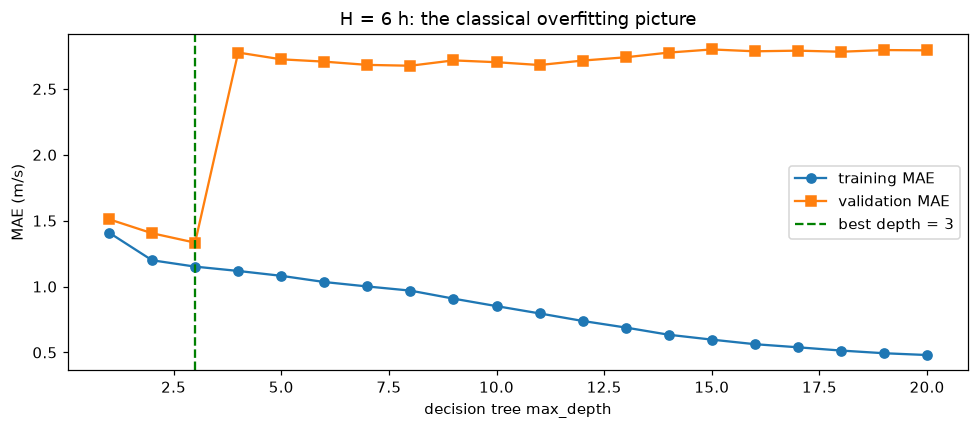

depth  train MAE   val MAE
   1   1.4095      1.5110
   5   1.0815      2.7249
   9   0.9083      2.7167
  13   0.6890      2.7402
  17   0.5390      2.7906

Training error falls monotonically towards zero; validation error falls and
then rises. The gap at large depth IS the overfitting. The best depth is
selected on the VALIDATION block - never on the test block.


In [5]:
# Overfitting, made visible: decision-tree depth versus train and validation error.
H_DEMO = 6
D = DATA[H_DEMO]
X_tr, y_tr, X_va, y_va = D['X_train'], D['y_train'], D['X_val'], D['y_val']

depths = range(1, 21, 1)
train_err, val_err = [], []
for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=5, random_state=SEED)
    tree.fit(X_tr, y_tr)
    train_err.append(metrics(y_tr, tree.predict(X_tr))['MAE'])
    val_err.append(metrics(y_va, tree.predict(X_va))['MAE'])

best_depth = list(depths)[int(np.argmin(val_err))]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(depths), train_err, marker='o', label='training MAE')
ax.plot(list(depths), val_err, marker='s', label='validation MAE')
ax.axvline(best_depth, color='green', ls='--', label='best depth = {}'.format(best_depth))
ax.set_xlabel('decision tree max_depth')
ax.set_ylabel('MAE (m/s)')
ax.set_title('H = {} h: the classical overfitting picture'.format(H_DEMO))
ax.legend()
plt.tight_layout()
plt.show()

print('depth  train MAE   val MAE')
for d, a, b in list(zip(depths, train_err, val_err))[::4]:
    print('  {:>2d}   {:.4f}      {:.4f}'.format(d, a, b))
print()
print('Training error falls monotonically towards zero; validation error falls and')
print('then rises. The gap at large depth IS the overfitting. The best depth is')
print('selected on the VALIDATION block - never on the test block.')

In [6]:
# Consolidated report: baselines and models, per horizon.
rows = []
for H in HORIZONS:
    for name, d in BASE[H].items():
        rows.append({'horizon_h': H, 'model': name, 'family': 'baseline',
                     'MAE': d['metrics']['MAE'], 'RMSE': d['metrics']['RMSE'],
                     'MSE': d['metrics']['MSE'], 'R2': d['metrics']['R2'],
                     'skill_vs_persistence': 1.0 - d['metrics']['MAE'] / BASE[H]['Persistence']['metrics']['MAE'],
                     'train_MAE': np.nan})
    for name, r in RESULTS[H].items():
        rows.append({'horizon_h': H, 'model': name, 'family': 'model',
                     'MAE': r['val']['MAE'], 'RMSE': r['val']['RMSE'],
                     'MSE': r['val']['MSE'], 'R2': r['val']['R2'],
                     'skill_vs_persistence': r['skill_vs_persistence'],
                     'train_MAE': r['train']['MAE']})

SCOREBOARD = pd.DataFrame(rows).sort_values(['horizon_h', 'MAE'])
print('Validation scoreboard (sorted by MAE within each horizon):')
print(SCOREBOARD.round(4).to_string(index=False))

print()
print('MAE matrix (rows = model, columns = horizon in hours):')
pivot_mae = SCOREBOARD.pivot(index='model', columns='horizon_h', values='MAE')
print(pivot_mae.round(3).to_string())

print()
print('Skill against persistence (positive = better than persistence):')
pivot_skill = SCOREBOARD.pivot(index='model', columns='horizon_h', values='skill_vs_persistence')
print((100 * pivot_skill).round(1).to_string())

Validation scoreboard (sorted by MAE within each horizon):
 horizon_h               model   family    MAE   RMSE     MSE      R2  skill_vs_persistence  train_MAE
         3                 SVR    model 0.9783 1.3857  1.9202  0.2661                0.1264     0.8410
         3       Random Forest    model 1.0029 1.3618  1.8544  0.2912                0.1045     0.3662
         3       Decision Tree    model 1.0771 1.5837  2.5081  0.0413                0.0382     0.8341
         3         Persistence baseline 1.1200 1.6163  2.6125  0.0015                0.0000        NaN
         3   Linear Regression    model 1.1949 1.5298  2.3404  0.1054               -0.0669     1.0212
         3 Diurnal climatology baseline 1.5142 1.7998  3.2391 -0.2381               -0.3521        NaN
         3         Climatology baseline 1.5655 1.8521  3.4302 -0.3111               -0.3978        NaN
         6                 SVR    model 1.0200 1.4769  2.1812  0.1638                0.3178     0.9135
         6    

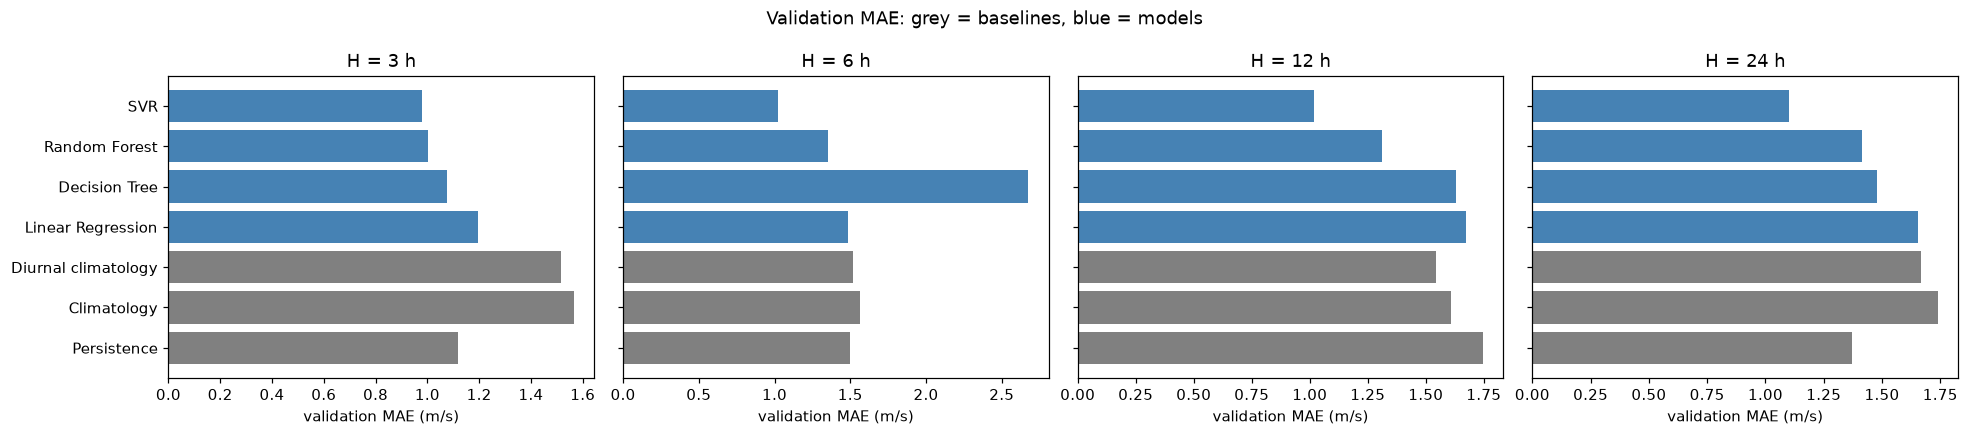

Read this figure before reading any table: at which horizon is the spread
between the best and the worst method the largest? That is where the modelling
effort buys the most, and it is also where a baseline would have been easiest
to beat - which is why the baseline must always be reported.


In [7]:
# Visual comparison: MAE per horizon, baselines and models side by side.
order = ['Persistence', 'Climatology', 'Diurnal climatology', 'Linear Regression',
         'Decision Tree', 'Random Forest', 'SVR']
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, H in zip(axes, HORIZONS):
    vals = [pivot_mae.loc[m, H] for m in order]
    colors = ['grey' if m in ('Persistence', 'Climatology', 'Diurnal climatology') else 'steelblue' for m in order]
    ax.barh(order, vals, color=colors)
    ax.set_title('H = {} h'.format(H))
    ax.set_xlabel('validation MAE (m/s)')
    ax.invert_yaxis()
axes[0].set_ylabel('')
plt.suptitle('Validation MAE: grey = baselines, blue = models')
plt.tight_layout()
plt.show()

print('Read this figure before reading any table: at which horizon is the spread')
print('between the best and the worst method the largest? That is where the modelling')
print('effort buys the most, and it is also where a baseline would have been easiest')
print('to beat - which is why the baseline must always be reported.')

---

## 5. What the numbers tell us

Look at your own scoreboard and answer these questions in your notebook:

1. **Does any model beat persistence at every horizon?** If not, the horizon where it fails is the most interesting result in the session.
2. **Where does the diurnal climatology beat the machine-learning models?** If it does, say so plainly. A physical, one-line baseline outperforming a forest on a winter test block is a legitimate and publishable observation, not an embarrassment.
3. **Is linear regression far behind the forests?** If the gap is large, the relationship is strongly non-linear. If the gap is small, the problem is dominated by an almost linear signal (typically the current wind speed) and extra model complexity is not paying for itself.
4. **Is SVR competitive?** SVR is sensitive to `C` and `epsilon`; a disappointing score may say more about those defaults than about the method. Session 4 gives you the tools to tune it.
5. **What is the train/validation gap for each model?** A forest with a huge gap is memorising the training block; that is worth a sentence in the discussion.

### Interpreting the metrics in physical units

- MAE of 1.4 m/s at H = 6 h means: *in a typical hour, our forecast is off by about 1.4 m/s*, against a target whose standard deviation is about 2.4 m/s. Useful context, not a failure.
- RMSE > MAE always (squared errors weight the tail); the ratio RMSE/MAE tells you how heavy the error tail is. A ratio near 1 means many small errors; a ratio well above 1.5 means a few large errors dominate - typical at 24 h, when storms are missed.
- R2 can be negative. If a model has a negative R2 it is worse than predicting the training mean, whatever else the table says.

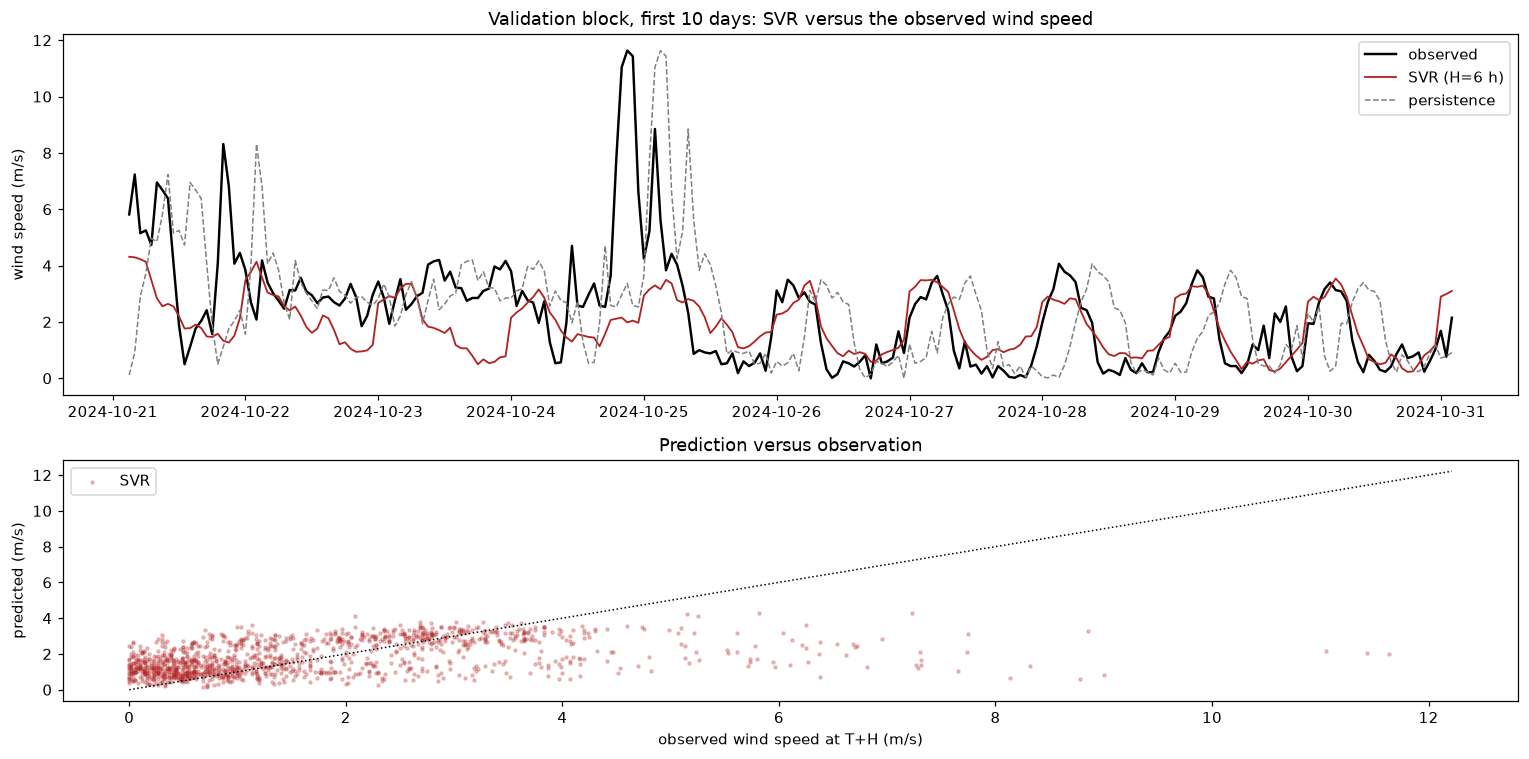

What to look for in the scatter:
  - points below the 1:1 line at high observed wind speeds = the model
    systematically under-predicts strong events (it regresses to the mean,
    and no tree can extrapolate beyond the training range).
  - spread widens to the right: errors grow with wind speed.
  - a cloud, not a line: even the best model leaves real uncertainty -
    which is why a deterministic forecast should always be accompanied by an
    error estimate (an exercise in Session 6).


In [8]:
# One model, one horizon, in detail: prediction vs observation on the validation block.
H_PLOT = 6
best_name = pivot_mae.loc[MODEL_NAMES, H_PLOT].idxmin()
series = pd.Series(RESULTS[H_PLOT][best_name]['pred'], index=DATA[H_PLOT]['X_val'].index)
obs = DATA[H_PLOT]['y_val']
persist = pd.Series(BASE[H_PLOT]['Persistence']['pred'], index=DATA[H_PLOT]['X_val'].index)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 2]})
zoom = slice(0, 24 * 10)   # first ten days of the validation block
axes[0].plot(obs.index[zoom], obs.values[zoom], color='black', lw=1.6, label='observed')
axes[0].plot(series.index[zoom], series.values[zoom], color='firebrick', lw=1.2, label=best_name + ' (H={} h)'.format(H_PLOT))
axes[0].plot(persist.index[zoom], persist.values[zoom], color='grey', lw=1.0, ls='--', label='persistence')
axes[0].legend()
axes[0].set_ylabel('wind speed (m/s)')
axes[0].set_title('Validation block, first 10 days: {} versus the observed wind speed'.format(best_name))

axes[1].scatter(obs.values, series.values, s=4, alpha=0.25, color='firebrick', label=best_name)
lim = [0, max(obs.max(), series.max()) * 1.05]
axes[1].plot(lim, lim, color='black', lw=1, ls=':')
axes[1].set_xlabel('observed wind speed at T+H (m/s)')
axes[1].set_ylabel('predicted (m/s)')
axes[1].set_title('Prediction versus observation')
axes[1].legend()
plt.tight_layout()
plt.show()

print('What to look for in the scatter:')
print('  - points below the 1:1 line at high observed wind speeds = the model')
print('    systematically under-predicts strong events (it regresses to the mean,')
print('    and no tree can extrapolate beyond the training range).')
print('  - spread widens to the right: errors grow with wind speed.')
print('  - a cloud, not a line: even the best model leaves real uncertainty -')
print('    which is why a deterministic forecast should always be accompanied by an')
print('    error estimate (an exercise in Session 6).')

---

## 6. Common pitfalls

**Pitfall 1 - reporting a metric with no baseline.**  
Always publish the persistence number in the same table.

**Pitfall 2 - scaling SVR's inputs but forgetting the target's units.**  
If you scale `y` in, you must inverse-transform the prediction before computing MAE. Better still: do not scale `y` at all for regression with a linear-ish estimator.

**Pitfall 3 - fitting the scaler once on the full record.**  
Use `Pipeline`, always.

**Pitfall 4 - choosing the model by its validation score after looking at the test score.**  
Every glance at the test block is a selection event. Session 7 is where the test block is opened - once.

**Pitfall 5 - comparing two models trained on different data.**  
Two models are comparable only on the same split, the same target and the same rows. Our SVR subsample is a deliberate exception and must be reported as such.

**Pitfall 6 - a suspiciously good score.**  
The largest R2 in the history of student projects is usually a leak. Session 2 gives you the checklist; use it before you believe an R2 above ~0.9 for a 24-hour wind forecast.

**Pitfall 7 - `mean_squared_error(..., squared=False)` confusion.**  
Newer versions of scikit-learn removed that argument. Take the square root of `MSE` yourself - it is unambiguous and version-proof.

**Pitfall 8 - believing that RMSE and R2 tell you the same thing.**  
RMSE is in m/s and is dominated by storms; R2 compares you with the mean of the block. Report both, plus MAE, and interpret them separately.

**Pitfall 9 - forgetting that a tree cannot extrapolate.**  
A model trained on a year with a maximum of 18 m/s has no mechanism to forecast 25 m/s. State the training range in the limitations section.

---

## 7. AI-assisted workflow

### 7.1 Prompts that help in this session

| Goal | Prompt |
|---|---|
| implement a metric set | 'Write a function that returns MAE, MSE, RMSE and R2 for two arrays, with a comment on the units and on when R2 is meaningless. Do not use version-dependent arguments.' |
| implement a baseline | 'How do I compute a diurnal-climatology baseline for an H-hour-ahead wind forecast without using any data from the validation period? Give pandas code and state the leakage constraint explicitly.' |
| diagnose a result | 'My random forest has train MAE = 0.35 and validation MAE = 1.60 m/s with 6,000 training rows and 60 features. List the likely causes in order and the cheapest diagnostic for each.' |
| sanity-check a comparison | 'I compare four models on a time-series split. What must be identical across the models for the comparison to be fair? Give a checklist.' |

### 7.2 Debugging prompt template

```
This code should fit an SVR and report MAE in m/s, but the MAE is 0.02 m/s,
which is impossible for a 6-hour wind forecast.
Here is the code: <paste>
Here are the dtypes and a few rows: <paste>
What is the most likely cause, how do I verify it in one line, and what is the fix?
```

Common root causes of an impossible MAE: the target was left scaled, the split overlapped, a `shift(-1)` got into the features, or the prediction was compared with the wrong row alignment.

### 7.3 Reviewing an AI answer about metrics

Ask the model: *'For a right-skewed target, which is more sensitive to rare events, MAE or RMSE? Show it with a two-point example.'* Then verify numerically. If you can construct a small array where MAE looks fine and RMSE explodes, you understand the metrics - and you can no longer be fooled by a single-number summary.

### 7.4 Validation checklist for this session

1. **Shapes and alignment.** `len(y_val) == len(pred)`. Print both.
2. **Units.** Every metric must be in m/s. If you scaled `y`, inverse-transform before scoring.
3. **Same rows for everyone.** All models and baselines scored on the identical validation index.
4. **Baseline present.** No table without persistence.
5. **Train-versus-validation gap** printed for every model (this catches overfitting *and* leakage).
6. **Determinism.** Re-run a model with the same `random_state` and confirm identical metrics. If the numbers move, you have an uncontrolled source of randomness.
7. **No test leakage.** Grep your code for `y_test` before Session 7.

### 7.5 Exercise

Ask an LLM for 'the best model for hourly wind speed forecasting'. You will get a confident answer naming XGBoost or an LSTM. Then ask a follow-up: *'What baseline must it beat, on what split, and what happens to that claim if the test period is a winter with different statistics?'* The difference in the quality of the two answers is the lesson: models are cheap to name, evidence is what costs work.

---

## 8. Exercises

### Level 1 - understanding

1. Write the three baseline definitions from memory, including the exact timestamp each one uses.
2. Why can the 24-hour persistence RMSE be lower than the 12-hour RMSE? What does that imply for evaluating a 24-hour model?
3. Define the skill score and explain what `skill = -0.05` means operationally.
4. Which model in the table cannot extrapolate, and why?

### Level 2 - implementation

5. Implement a fourth baseline: the **training-period mean per calendar month and hour of day**. Compare it with the diurnal climatology.
6. Implement a **climatological persistence** baseline: predict the wind speed at the same hour of the previous day.
7. Add Ridge and Lasso regressions (inside pipelines) and compare them with ordinary linear regression. Does regularisation help at all?
8. Add a K-Nearest-Neighbours regressor (with a scaler) and discuss why it is a poor choice for a 60-dimensional feature space.
9. Train all four models at `H = 1` (one hour ahead) as well. How does the ranking of the models change with the horizon?

### Level 3 - reasoning

10. Your random forest has a much larger train/validation gap than linear regression, yet a better validation MAE. Explain how both statements can be true, and which number you would report.
11. SVR was trained on a subsample of the training block. Argue for and against reporting it in the same table as the other models.
12. Explain why a model with `R2 = 0.15` at 24 h may still be operationally valuable, using the persistence baseline as your reference.
13. The validation block is autumn/winter. Predict how the ranking of models would change if the test block were summer, and describe the experiment that would test your prediction.

### Level 4 - application (project work)

14. **Write the baselines section of your report.** One paragraph, with a table of persistence / climatology / diurnal-climatology MAE, RMSE and R2 at all four horizons, and one sentence on which baseline is the strongest per horizon.
15. **Choose and defend a working model.** Using only the validation block, select the model you would carry forward, and write three sentences justifying it in terms of (a) accuracy versus the best baseline, (b) robustness across horizons and (c) interpretability or operational cost. Note the horizon at which your choice is weakest.

---

## 9. Reproducibility notes

- **Same data path, same cleaning, same split as Session 2.** No result in this notebook would survive a different split, so the split is frozen by row index.
- **Seeds.** `SEED = 42` governs the forest, the SVR subsample and any tie-breaking. Re-running must reproduce the tables exactly.
- **Two toggles to report.** `QUICK_MODE` (which sets `N_TREES` and `SVR_MAX_TRAIN`) and every hyper-parameter in `make_model`.
- **Fit times are recorded** for every model and horizon; they belong in your report because an operational forecast has a latency budget.
- **The test block is loaded but never scored.** Verify it: no `y_test` in any metric in this notebook.
- **Nothing is written to disk.** Models live in memory; Session 7 shows how to serialise one safely *in memory* for a reproducibility check.

---

## 10. Key takeaways

1. A forecast is only meaningful relative to a baseline; for wind speed, persistence is a strong baseline and the diurnal climatology is a serious one at long horizons.
2. On the same purged chronological split, we can now compare four classical models fairly.
3. Every metric lives in m/s, and the skill score against persistence is the number to quote.
4. The train/validation gap diagnoses overfitting; the decision-tree depth curve shows the mechanism.
5. Trees cannot extrapolate, so strong-wind events are systematically under-predicted - a first, concrete scientific limitation of these models.
6. Model selection happens on the validation block only. The test block is still untouched.

In [9]:
# ===========================================================================
# FINAL VALIDATION CELL - run last, in every notebook
# ===========================================================================
WARNINGS = []
if QUICK_MODE:
    WARNINGS.append('QUICK_MODE=True: forest uses {} trees; a 300-tree forest will be slightly better'.format(N_TREES))
WARNINGS.append('SVR trained on a random subsample of at most {} training rows (runtime), so its score is not directly comparable'.format(SVR_MAX_TRAIN))
WARNINGS.append('validation block is autumn/winter while training covers spring/summer: absolute scores are pessimistic relative to a same-season evaluation')
best_overall = SCOREBOARD.loc[SCOREBOARD['family'] == 'model'].sort_values('MAE').iloc[0]

manifest = {
    'notebook': '03_baselines_and_classical_ml_abali.ipynb',
    'session': 'Session 3 - baselines and first classical models',
    'dataset_used': RAW_PATH + ' (Abali station, hourly, cleaned in memory)',
    'target_variable': 'wind_speed_ms at T + H (m/s), direct multi-horizon',
    'forecast_horizons_hours': HORIZONS,
    'evaluated_on': 'validation block only ({} to {})'.format(DATA[HORIZONS[0]]['X_val'].index[0].date(), DATA[HORIZONS[0]]['X_val'].index[-1].date()),
    'baselines': ['Persistence', 'Climatology', 'Diurnal climatology (training period, by hour of target time)'],
    'models_used': MODEL_NAMES,
    'metrics_used': ['MAE', 'MSE', 'RMSE', 'R2', 'skill_vs_persistence'],
    'mae_by_horizon': {str(H): {m: float(pivot_mae.loc[m, H]) for m in order if m in pivot_mae.index} for H in HORIZONS},
    'best_model_overall_by_MAE': str(best_overall['model']) + ' at H = ' + str(int(best_overall['horizon_h'])) + ' h',
    'test_block_touched': False,
    'files_written': 'none (all work in memory)',
    'random_seed': SEED,
    'warnings': WARNINGS,
}
print(json.dumps(manifest, indent=2, default=str))

{
  "notebook": "03_baselines_and_classical_ml_abali.ipynb",
  "session": "Session 3 - baselines and first classical models",
  "dataset_used": "../../data/raw/abali.xlsx (Abali station, hourly, cleaned in memory)",
  "target_variable": "wind_speed_ms at T + H (m/s), direct multi-horizon",
  "forecast_horizons_hours": [
    3,
    6,
    12,
    24
  ],
  "evaluated_on": "validation block only (2024-10-21 to 2024-12-28)",
  "baselines": [
    "Persistence",
    "Climatology",
    "Diurnal climatology (training period, by hour of target time)"
  ],
  "models_used": [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "SVR"
  ],
  "metrics_used": [
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "skill_vs_persistence"
  ],
  "mae_by_horizon": {
    "3": {
      "Persistence": 1.1199533437013998,
      "Climatology": 1.5654737483381118,
      "Diurnal climatology": 1.514241720861893,
      "Linear Regression": 1.1948585678041763,
      "Decision Tree": 1.07714734229139

---

### What comes next

In **Session 4** we add the modern workhorses and the machinery to tune them honestly:

- gradient boosting with **XGBoost** and **LightGBM** (with a graceful fallback if they are not installed);
- `TimeSeriesSplit` cross-validation with a gap, inside the training block only;
- a **randomised hyper-parameter search** evaluated with time-aware folds;
- a fair comparison of the tuned ensemble against the best classical model from this session.

Before then, finish exercises 5, 10 and 14 - exercise 14 is the baselines section of your report.